# Preprocessing pipeline

Stuff for preprocessing the data

___

## Data onboarding and preprocessing

### Load data

In [9]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.typing import NDArray

np.random.seed(42)

dir_path = "../training_data"

names, labels, datas = [], [], []
for label in range(10): 
    for file_path in [os.path.join(dir_path, f) for f in os.listdir(dir_path) if ".csv" in f and f"stroke_{label}" in f]: 
        names.append(os.path.splitext(os.path.basename(file_path))[0])
        labels.append(label)
        datas.append(pd.read_csv(file_path, header=None))

In [10]:
plots_dir = "plots"

for name, data, label in zip(names, datas, labels):
    x, y, z = data[0], data[1], data[2]
    plt.figure()
    plt.plot(x, y)
    plt.title(f"{label}")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.axis("equal")
    plt.savefig(os.path.join(plots_dir, f"{name}.png"))
    plt.close()

### Project to 2D

In [11]:
from sklearn.decomposition import PCA

# Define function to project 3D data to 2D using PCA
def project_to_2d(data: pd.DataFrame|NDArray, keep_order: bool=True, keep_dims: bool=False) -> NDArray:
    
    # Convert data to numpy array if needed
    if isinstance(data, pd.DataFrame): data = data.to_numpy()

    # Calculate the variances in each dimension and sort dimensions by variance

    # Apply PCA
    pca = PCA(n_components=data.shape[1]).fit(data)
    scores = pca.fit_transform(data)
    loadings = pca.components_ 

    # Find principal components that align best with the original axes
    order = np.argmax(np.abs(loadings), axis=0)[:(data.shape[1] if keep_dims else 2)]

    # Return reordered projected data
    return scores[:, order]

In [12]:
# Define variables for PCA usage
use_PCA = True

if use_PCA:
    
    # Project the features to 2D using PCA without weights
    projected_features = [project_to_2d(data) for data in datas]

else: 

    # Just use the original features without projection
    projected_features = [data[:, :2].to_numpy() for data in datas]

### Convert data to images

In [13]:
from typing import List

# Define a function to convert 2D/3D coordinates to images
def convert_to_image(data_projected: NDArray, size: tuple) -> NDArray: 

    # Initialize empty image
    width, height = size 
    image = np.zeros((height, width))

    # Center and scale the data to range [-1, 1]
    min_values, max_values = np.min(data_projected, axis=0), np.max(data_projected, axis=0)
    data_projected = data_projected - (min_values + max_values) / 2
    data_projected = data_projected / np.max(np.abs(data_projected)) # Scale to range [-1, 1]

    # Extract x and y data and scale to [0, N-1] (pixel coordinates)
    x_data, y_data = data_projected[:, 0], data_projected[:, 1] # Note: swap x and y for image coordinates
    x_data = x_data * ((width-1) / 2) + ((width-1) / 2)
    y_data = y_data * ((height-1) / 2) + ((height-1) / 2)

    # Compute floor and ceil values
    x_floor, x_ceil = np.floor(x_data).astype(int), np.ceil(x_data).astype(int)
    y_floor, y_ceil = np.floor(y_data).astype(int), np.ceil(y_data).astype(int)

    # Convert x, y data to pixels in an image
    image[y_floor, x_floor] += (1 - y_data % 1) * (1 - x_data % 1)
    image[y_ceil, x_ceil] += (y_data % 1) * (x_data % 1)
    image[y_floor, x_ceil] += (x_data % 1) * (1 - y_data % 1)
    image[y_ceil, x_floor] += (1 - x_data % 1) * (y_data % 1)

    # Clip the pixel values to range [0, 1]
    image = np.clip(image, 0, 1)  

    # Flip the image (so that it is not upside down)
    image = np.flip(image, 0)
    
    return image

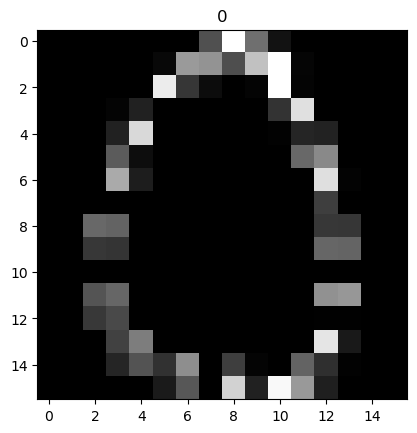

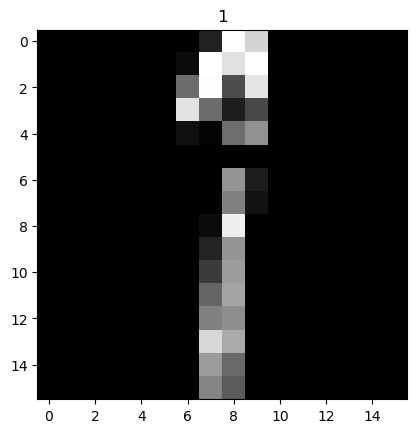

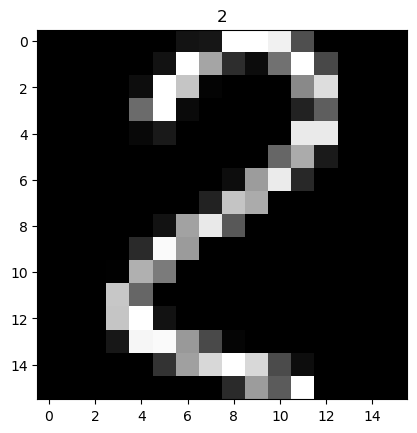

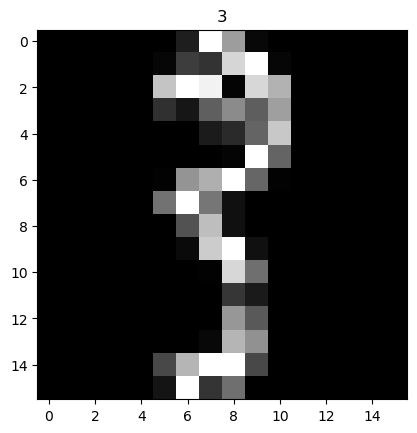

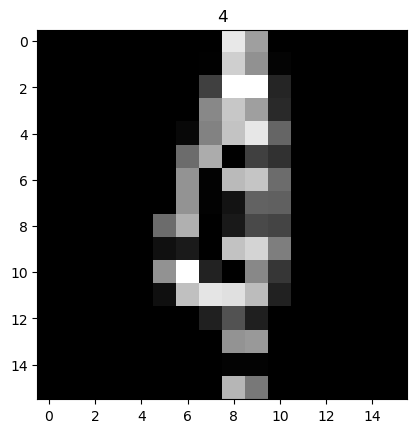

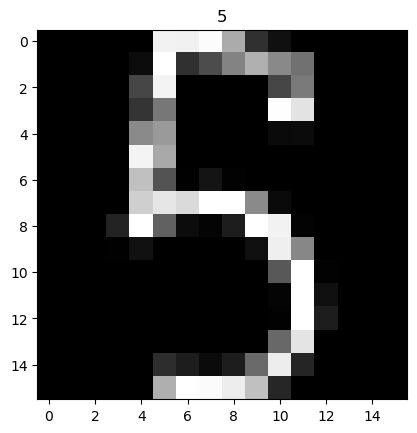

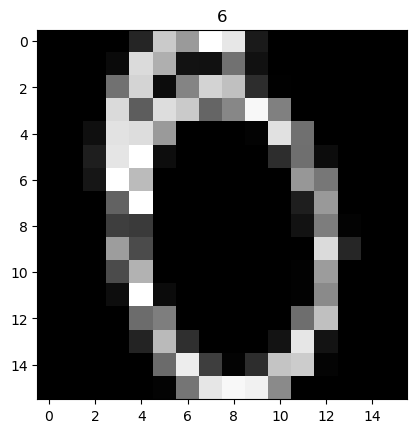

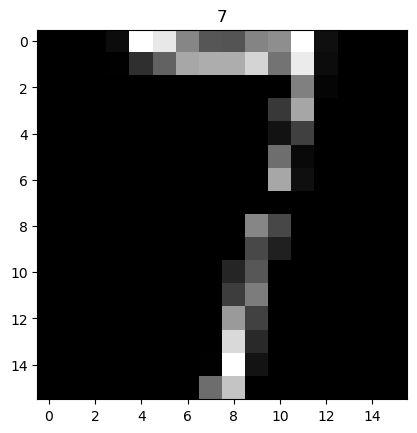

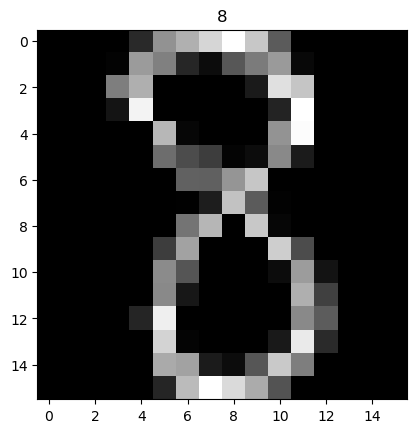

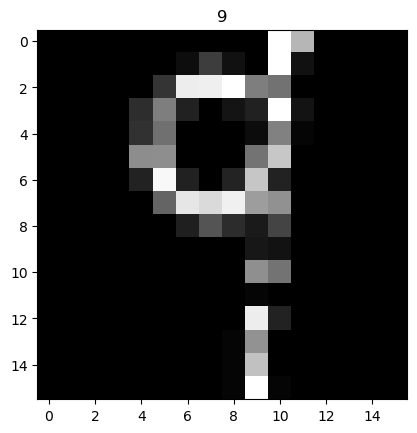

In [14]:
# Choose image size
image_size = (16, 16)

# Convert projected features to images
images = [convert_to_image(p, image_size) for p in projected_features]

# Show some images
for label, image in zip(labels[:1000:100], images[:1000:100]): 
    plt.figure()
    plt.imshow(image, cmap='Grays_r')
    plt.title(label)

### Stack images and labels to arrays

In [15]:
X = np.stack(images)
y = np.array(labels)
print(X.shape, y.shape)

(1000, 16, 16) (1000,)


In [16]:
img_dir = "images"
for i, (name, label, image) in enumerate(zip(names, labels, images)): 
    plt.figure()
    plt.imshow(image, cmap='Grays_r')
    plt.title(label)
    plt.savefig(os.path.join(img_dir, f"{name}.png" ))
    plt.close()